# Single Circuit Active Learning

Reference example showing the Active Learning loop running on a **single circuit**.
Use this to understand how each component (Designer, Lab, Learner) operates cycle-by-cycle.

Compared to notebook `07_run_api.ipynb`, this shows the internals rather than hiding them in `ActiveLearningLoop`.

In [1]:
import os
# Navigate to repo root so all relative paths resolve correctly.
if os.path.basename(os.getcwd()) in ('notebooks', 'examples'):
    os.chdir('..')

In [2]:
import copy
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

from gcad.circuit import Topo  # required for pickle deserialization
from gcad.equations import system_equations_DsRed_pop
from active_learning.config import ActiveLearningConfig
from active_learning.lab import VirtualLab
from active_learning.designer import ExperimentDesigner
from active_learning.learner import Learner
from active_learning.utils import generate_dynamic_targets, generate_prior_ensemble

## Load Circuit and Configure

In [3]:
# Load circuits from the main notebook pipeline output
# Adjust CIRCUIT_IDX to select a different circuit (0, 1, 2, ...)
CIRCUIT_IDX = 0

with open(os.path.join("data", "selected_M_circuits.pkl"), "rb") as f:
    circuits_list = pickle.load(f)

target_circuit = circuits_list[CIRCUIT_IDX]
circuit_dict = {"Circuit_1": target_circuit}

print(f"Circuit edges: {target_circuit.edge_list}")
print(f"Nominal doses: {target_circuit.dose}")

Circuit edges: [('P1', 'Z6'), ('Z6', 'Z6'), ('Z6', 'Rep'), ('Z6', 'I13'), ('I13', 'Z6')]
Nominal doses: {'Rep': 200, 'I13': 25, 'Z6': 70}


In [4]:
config = ActiveLearningConfig(
    ensemble_size=150,
    spread_factor=2.0,
    dist_type='lognormal',
    budget_circuits=1,
    budget_dosages=1,
    dosages=list(np.round(np.arange(0.2, 4.2, 0.4), 2)),
    measurement_noise_std=5.0,
    perturbation_scale=0.1,
    selection_ratio=0.2,
    max_cycles=6
)

## Define Synthetic Ground Truth

In [5]:
# Load nominal parts and generate a synthetic ground truth
from gcad.loader import parts as nominal_parts, promo as promo_params

true_parts = {k: v.copy() if hasattr(v, 'copy') else v for k, v in nominal_parts.items()}

from gcad.loader import parts as nominal_parts, promo as promo_params

true_parts = {k: v.copy() if hasattr(v, 'copy') else v for k, v in nominal_parts.items()}

# Mutate Z6: Kd 25% stronger, ymax 25% stronger
true_parts['Z6'] = np.array([0.015, 72.5, nominal_parts['Z6'][2]])
# Mutate I13: Kd 25% stronger
true_parts['I13'] = np.array([0.009])

print("Ground truth mutations applied.")

Loaded 12 Activators and 12 Inhibitors.
Ground truth mutations applied.


## Generate Prior Ensemble

In [6]:
np.random.seed(42)
targets = generate_dynamic_targets(list(circuit_dict.values()))
belief_cloud = generate_prior_ensemble(nominal_parts, targets, config)
print(f"Generated {{len(belief_cloud)}} prior models. Targets: {{list(targets.keys())}}")

Generated {len(belief_cloud)} prior models. Targets: {list(targets.keys())}


## Initialize Modules

In [7]:
lab = VirtualLab(circuit_dict, true_parts, promo_params, config)
designer = ExperimentDesigner(circuit_dict, config)
learner = Learner(circuit_dict, targets, config)
print("Lab, Designer, and Learner initialized.")

Lab, Designer, and Learner initialized.


## Run the Loop


 Cycle 0


[Designer] Simulating Grid: 100%|██████████| 10/10 [00:35<00:00,  3.50s/exp]



[Learner] Assessing 150 models against 1 experiments
[Learner] Selected top 30 candidates.
[Learner] Best Total NMSE: 6.7467e-03


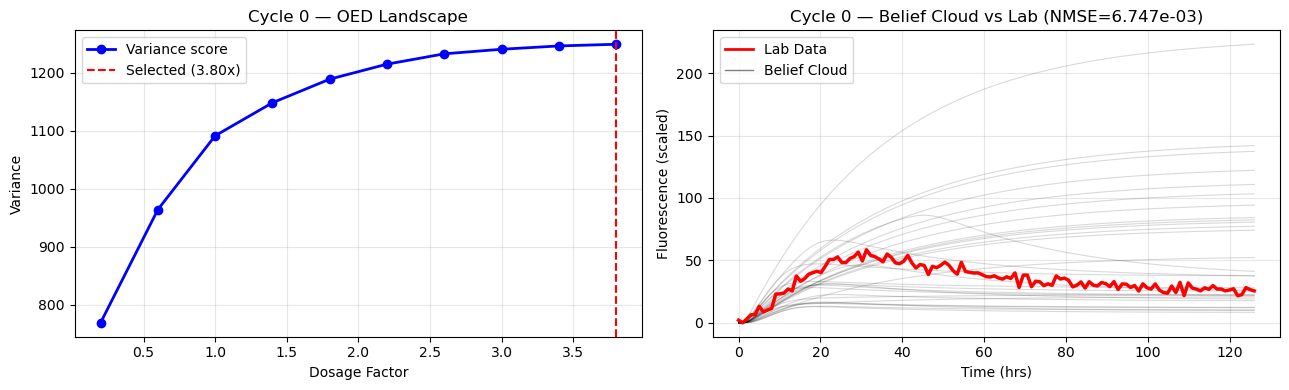


 Cycle 1


[Designer] Simulating Grid: 100%|██████████| 10/10 [00:37<00:00,  3.71s/exp]



[Learner] Assessing 150 models against 2 experiments
[Learner] Selected top 30 candidates.
[Learner] Best Total NMSE: 4.9937e-03


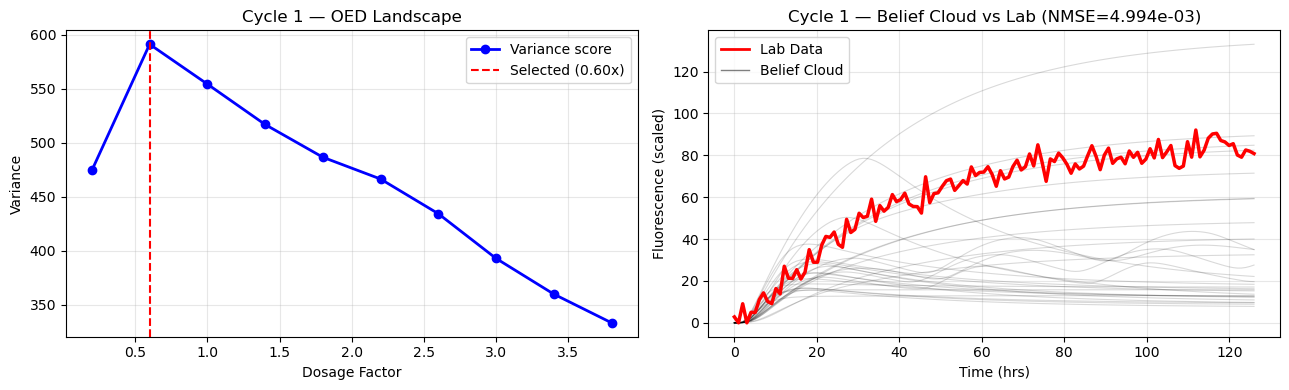


 Cycle 2


[Designer] Simulating Grid: 100%|██████████| 10/10 [00:37<00:00,  3.79s/exp]



[Learner] Assessing 150 models against 3 experiments
[Learner] Selected top 30 candidates.
[Learner] Best Total NMSE: 8.9554e-03


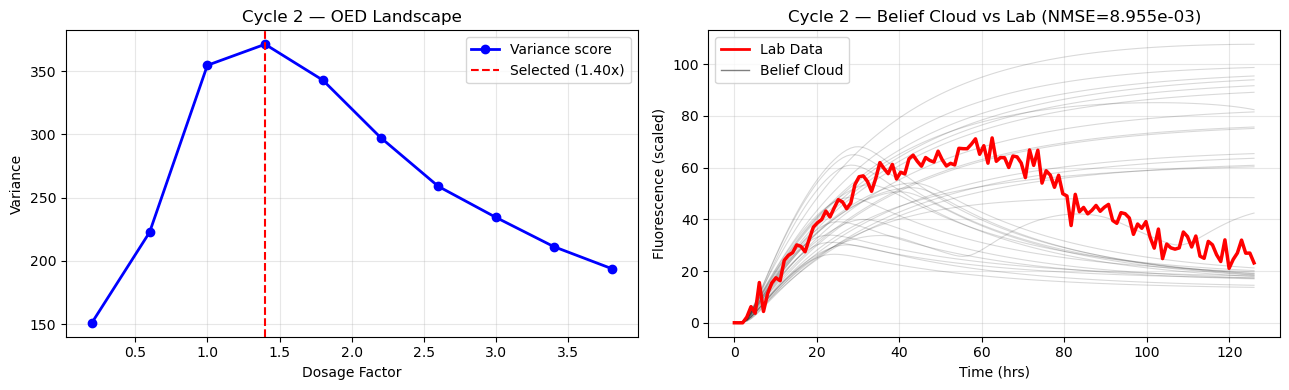


 Cycle 3


[Designer] Simulating Grid: 100%|██████████| 10/10 [00:38<00:00,  3.88s/exp]



[Learner] Assessing 150 models against 4 experiments
[Learner] Selected top 30 candidates.
[Learner] Best Total NMSE: 1.3195e-02


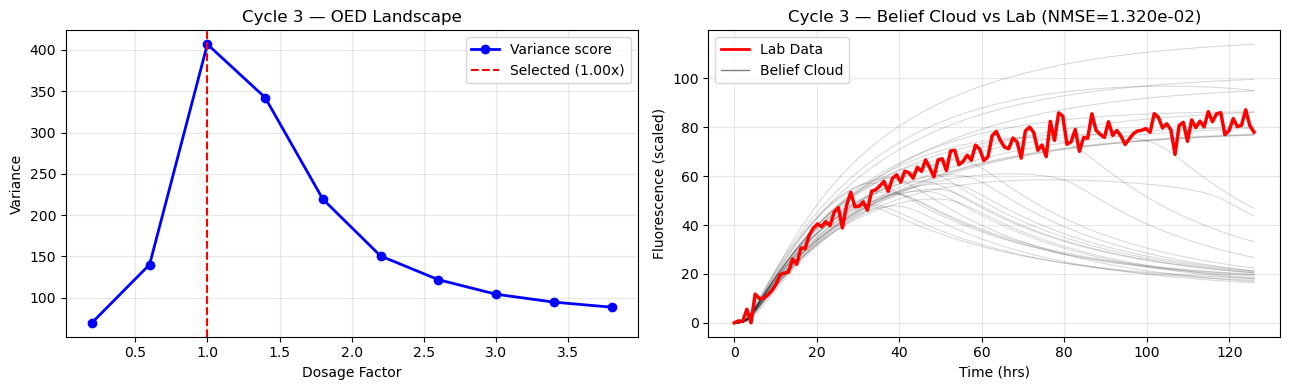


 Cycle 4


[Designer] Simulating Grid: 100%|██████████| 10/10 [00:39<00:00,  3.93s/exp]



[Learner] Assessing 150 models against 4 experiments
[Learner] Selected top 30 candidates.
[Learner] Best Total NMSE: 8.9570e-03


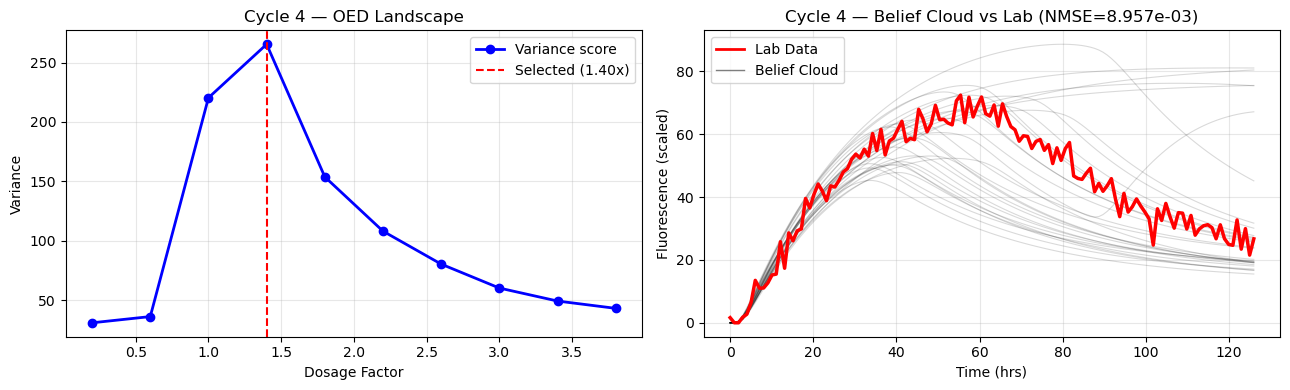


 Cycle 5


[Designer] Simulating Grid: 100%|██████████| 10/10 [00:46<00:00,  4.69s/exp]



[Learner] Assessing 150 models against 4 experiments
[Learner] Selected top 30 candidates.
[Learner] Best Total NMSE: 8.4290e-03


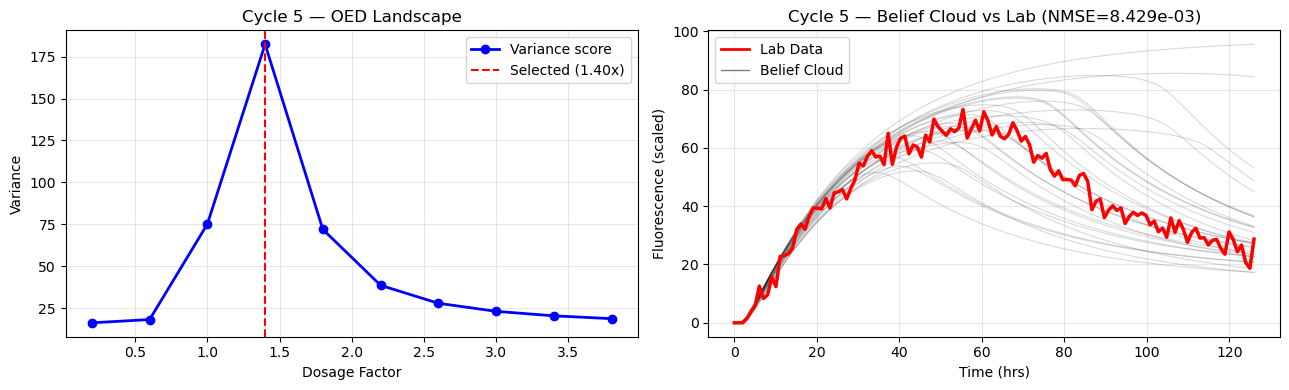


Active learning complete.


In [8]:
lab_data_dict = {}

for cycle in range(config.max_cycles):
    print(f"\n{'='*35}\n Cycle {cycle}\n{'='*35}")

    # 1. Design — find the most informative (circuit, dosage) pair
    selected_experiments, variance_matrix, all_sims = designer.design_experiment(belief_cloud, promo_params)
    best_dose = selected_experiments[0][1]
    dosages = config.dosages
    oed_scores = variance_matrix[0, :]  # single circuit: row 0

    # 2. Experiment — run the virtual lab
    t_span, y_lab = lab.run_experiment("Circuit_1", best_dose)
    lab_data_dict[("Circuit_1", best_dose)] = y_lab

    # 3. Update — ABC resampling
    belief_cloud, best_nmse = learner.update_belief(belief_cloud, promo_params, lab_data_dict)

    # 4. Visualize
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # OED landscape
    axes[0].plot(dosages, oed_scores, 'b-o', lw=2, label='Variance score')
    axes[0].axvline(best_dose, color='r', linestyle='--', label=f'Selected ({best_dose:.2f}x)')
    axes[0].set_title(f"Cycle {cycle} — OED Landscape")
    axes[0].set_xlabel("Dosage Factor")
    axes[0].set_ylabel("Variance")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Belief cloud vs lab data
    belief_traces = all_sims[("Circuit_1", best_dose)]
    axes[1].plot(t_span, y_lab, 'r-', lw=2.5, label='Lab Data', zorder=5)
    for trace in belief_traces[::5]:  # plot every 5th trace to keep figure fast
        axes[1].plot(t_span, trace, 'k-', alpha=0.15, lw=0.8)
    axes[1].set_title(f"Cycle {cycle} — Belief Cloud vs Lab (NMSE={best_nmse:.3e})")
    axes[1].set_xlabel("Time (hrs)")
    axes[1].set_ylabel("Fluorescence (scaled)")
    from matplotlib.lines import Line2D
    axes[1].legend([Line2D([0],[0],color='r',lw=2), Line2D([0],[0],color='k',lw=1,alpha=0.5)],
                   ['Lab Data', 'Belief Cloud'])
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("\nActive learning complete.")

## Results Summary

In [9]:
# Parameter posterior summary
print("\nPosterior mean vs ground truth:")
for part, indices in targets.items():
    for i in indices:
        posterior = np.array([m[part][i] for m in belief_cloud])
        mean_val = np.mean(posterior)
        truth_val = true_parts[part][i]
        nominal_val = nominal_parts[part][i]
        print(f"  {part}[{i}]:  nominal={nominal_val:.4f}  truth={truth_val:.4f}  AL mean={mean_val:.4f}")


Posterior mean vs ground truth:
  Z6[0]:  nominal=0.0162  truth=0.0150  AL mean=0.0203
  Z6[1]:  nominal=67.4289  truth=72.5000  AL mean=71.4602
  Z6[2]:  nominal=0.0342  truth=0.0342  AL mean=0.0387
  I13[0]:  nominal=0.0081  truth=0.0090  AL mean=0.0100
